In [1]:
import numpy as np
import torch
from delan import DeepLagrangianNetwork
from GravityCompensation_DeLAN import GravityCompensationLNN
from double_pendulum.simulation.simulation import Simulator
from double_pendulum.model.plant import DoublePendulumPlant
from double_pendulum.utils.plotting import plot_timeseries
%matplotlib inline
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['animation.writer'] = "pillow"

In [2]:
user_token="1747283276843825152"

In [3]:
model = DeepLagrangianNetwork(
    n_dof=2, learn_friction=True,
    n_width=64, n_depth=2, activation='SoftPlus',
    diagonal_epsilon=1e-3, b_diag_init=0.5,
)
ck = torch.load('delan_best_1.pt',
                map_location='cpu', weights_only=False)
model.load_state_dict(ck['model'])
model.eval()

DeepLagrangianNetwork(
  (layers): ModuleList(
    (0-1): 2 x LagrangianLayer(
      (g): Softplus(beta=1.0, threshold=20.0)
      (g_prime): SoftplusDer()
    )
  )
  (net_g): LagrangianLayer(
    (g): Linear()
    (g_prime): LinearDer()
  )
  (net_lo): LagrangianLayer(
    (g): Linear()
    (g_prime): LinearDer()
  )
  (net_ld): LagrangianLayer(
    (g): ReLU()
    (g_prime): ReLUDer()
  )
)

In [4]:
x0 = [2*np.pi/2.5, 0*np.pi/3, 0.0, 0.0]
ctrl = GravityCompensationLNN(torque_limit=[0.14, 0.14], scale=1, gen=0, mainc='delan_best91_sine_f1_1.pt', active="Sine")

activation fn is Sine


In [5]:
plant = DoublePendulumPlant(
    mass=[0.131, 0.064], length=[0.05, 0.05], com=[0.046, 0.048],
    gravity=9.81, inertia=[0.000277, 0.000147],
    damping=[0.002, 0.0004], torque_limit=[0.15, 0.15],
)
sim = Simulator(plant=plant)

In [6]:
T_exp, X_exp, U_exp, U_des_exp, vod, cell_id = sim.run_experiment(
    tf=8.0, dt=0.05, controller=ctrl,
    experiment_type='DoublePendulum',
    user_token=user_token, preparation_time=7.0,
    x0=x0, record=False,
)

Successfully reserved cell on the server
Livestream url:  http://cloudpendulum.m2.chalmers.se:5080/live/viewer.jsp?host=cloudpendulum.m2.chalmers.se&stream=camera_169
Starting experiment in 6 seconds
Starting experiment in 5 seconds
Starting experiment in 4 seconds
Starting experiment in 3 seconds
Starting experiment in 2 seconds
Starting experiment in 1 seconds
Starting experiment
Your session token is: 818722257118094336
Detected cell/camera: 169
n:160
Control Loop Started!
Initial state x: [ 2.10256052 -0.08245147  0.00477462 -0.04327504]
General Model is selected-delan_best91_sine_f1_1.pt
tau=[0.10456888 0.02514195]
tau=[0.10802963 0.02521266]
tau=[0.11128122 0.02597953]
tau=[0.1139381  0.02652111]
tau=[0.11625031 0.02704185]
tau=[0.11825002 0.02745535]
tau=[0.11956613 0.02770461]
tau=[0.12019417 0.0277996 ]
tau=[0.12040222 0.02782344]
tau=[0.1204232  0.02780807]
tau=[0.12041859 0.02780807]
tau=[0.12042537 0.02781542]
tau=[0.12041327 0.02782451]
tau=[0.12028995 0.02782294]
tau=[0.1

/tmp/ipykernel_554234/4086990246.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc='best', fontsize=9)
/tmp/ipykernel_554234/4086990246.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend(loc='best', fontsize=9)


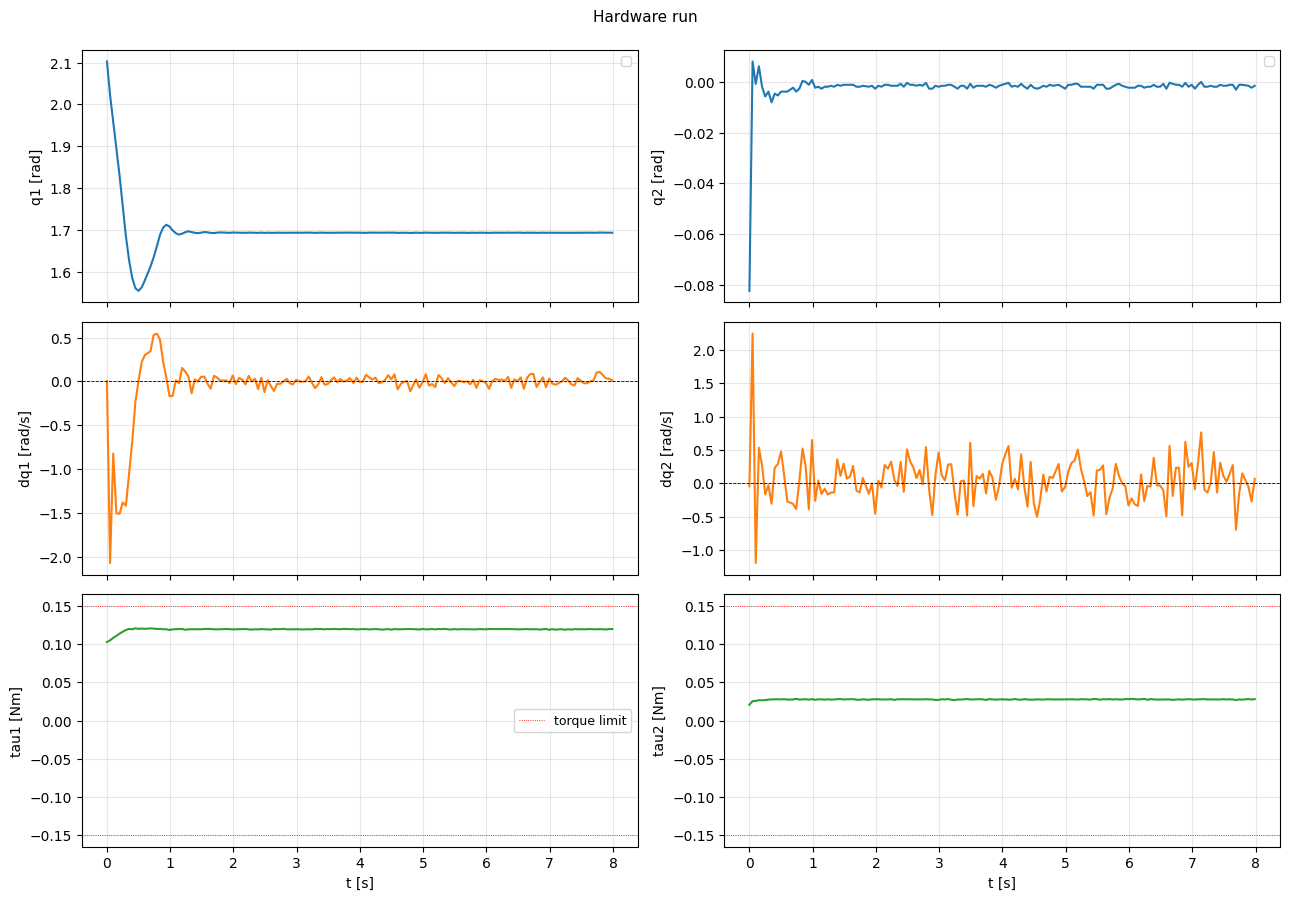

In [7]:
import numpy as np
import matplotlib.pyplot as plt

T_exp = np.asarray(T_exp)
X_exp = np.asarray(X_exp)
U_exp = np.asarray(U_exp)

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)

# Row 0: positions
axes[0, 0].plot(T_exp, X_exp[:, 0], color='C0')
# axes[0, 0].axhline(x0_print[0], color='k', ls='--', lw=0.6, label=f'target {x0_print[0]:.3f}')
axes[0, 0].set_ylabel('q1 [rad]')
axes[0, 0].legend(loc='best', fontsize=9)

axes[0, 1].plot(T_exp, X_exp[:, 1], color='C0')
# axes[0, 1].axhline(x0_print[1], color='k', ls='--', lw=0.6, label=f'target {x0_print[1]:.3f}')
axes[0, 1].set_ylabel('q2 [rad]')
axes[0, 1].legend(loc='best', fontsize=9)

# Row 1: velocities
axes[1, 0].plot(T_exp, X_exp[:, 2], color='C1')
axes[1, 0].axhline(0, color='k', ls='--', lw=0.6)
axes[1, 0].set_ylabel('dq1 [rad/s]')

axes[1, 1].plot(T_exp, X_exp[:, 3], color='C1')
axes[1, 1].axhline(0, color='k', ls='--', lw=0.6)
axes[1, 1].set_ylabel('dq2 [rad/s]')

# Row 2: torques
axes[2, 0].plot(T_exp, U_exp[:, 0], color='C2')
axes[2, 0].axhline( 0.15, color='r', ls=':', lw=0.6, label='torque limit')
axes[2, 0].axhline(-0.15, color='r', ls=':', lw=0.6)
axes[2, 0].set_ylabel('tau1 [Nm]')
axes[2, 0].set_xlabel('t [s]')
axes[2, 0].legend(loc='best', fontsize=9)

axes[2, 1].plot(T_exp, U_exp[:, 1], color='C2')
axes[2, 1].axhline( 0.15, color='r', ls=':', lw=0.6)
axes[2, 1].axhline(-0.15, color='r', ls=':', lw=0.6)
axes[2, 1].set_ylabel('tau2 [Nm]')
axes[2, 1].set_xlabel('t [s]')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Hardware run',
    fontsize=11, y=0.995,
)
plt.tight_layout()
plt.show()

# Summary stat